# Linear Regression

Linear Regression allows us to build arelationship between multiple features to estimate a target output

>Example: We want to estimate the price of a house given its features(like are in sq. ft., distance from the metro,number of beed rooms etc.) based on historical data we already have 

## Ordinary Least Square

We know that the equation of a simple straight line :

<b>$ y=mx+b $<b>

* where m is slope and b is intercept with y-axis
----------------------------------

* Here we can see for $y=mx+b$ there is only room for one possible feature x
* OLS will allow us to directly slope **m** and intercept **b**
* For multiple features however we need to take help of tools like **Gradient Descent** as we will see later on

## Generalized form

Suppose we have the following data :
| Area (m²) | Bedrooms | Bathrooms | Price     |
|-----------|-----------|------------|------------|
| 200       | 3         | 2          | $500,000   |
| 190       | 2         | 1          | $450,000   |
| 230       | 3         | 3          | $650,000   |
| 180       | 1         | 1          | $400,000   |
| 210       | 2         | 2          | $550,000   |

* Here this can fetures are- **Area($X_1$),Bedrooms($X_2$), Bathrooms($X_3$)**
* And the target variable is -**Price(y)**

| $x_1$     | $x_2$     | $x_3$      | y          |
|-----------|-----------|------------|------------|
| 200       | 3         | 2          | $500,000   |
| 190       | 2         | 1          | $450,000   |
| 230       | 3         | 3          | $650,000   |
| 180       | 1         | 1          | $400,000   |
| 210       | 2         | 2          | $550,000   |

This can then be eventually coverted into **Matrix** notation in the following manner:

|   $x_1$   |   $x_2$   |  $x_3$   |     y      |
|-----------|-----------|----------|------------|
|$x_1^1=200$|$x_2^1=3$  | $x_3^1=2$| $y_1=500000$|
|$x_1^2=190$|$x_2^2=2$  | $x_3^2=1$| $y_2=450000$|
|$x_1^3=230$|$x_2^3=3$  | $x_3^3=3$| $y_3=650000$|
|$x_1^4=180$|$x_2^4=1$  | $x_3^4=1$| $y_4=400000$|
|$x_1^5=210$|$x_2^5=2$  | $x_3^5=2$| $y_5=550000$|

In case of linear regression each of these features $x_1,x_2,x_3....$ should have a beta coeffiecient with it like: 

$\hat{y}^j=\beta_0x_0^j+\beta_1x_1^j+\beta_2x_2^j+\beta_3x_3^j+....$

$=>\hat{y}^j=\sum_{i=0}^{n}\beta_ix_i^j$ where $x_i^j$ is the jth observation of ith  feature 

>**Note**: Notice that instead of just y we are using $\hat{y}$. This is  because for real life data there is usually no set of betas to create a perfect fit to y

---------------------------------

For simple problems with one X feature we can easily solve for beta with an analytical solution

# Ordinary Least Squares (OLS) Regression: Simple Linear Regression from Scratch

## Problem Setup

Suppose we have a dataset containing one feature \(x\) and one target variable \(y\).

| Observation | x | y |
|------------|---|---|
| 1 | $x_1$ | $y_1$ |
| 2 | $x_2$ | $y_2$ |
| ... | ... | ... |
| n | $x_n$ | $y_n$ |

Our objective is to find the straight line that best describes the relationship between \(x\) and \(y\).

The regression line is defined as:

$$
\hat{y} = b_0 + b_1x
$$

where:

- $b_0$ = Intercept
- $b_1$ = Slope
- $\hat{y}$ = Predicted value of $y$

For each observation:

$$
\hat{y}_i = b_0 + b_1x_i
$$

---

## Interpretation of the Coefficients

### Intercept ($b_0$)

The intercept is the predicted value of \(y\) when \(x = 0\).

$$
\hat{y} = b_0
\quad \text{when } x = 0
$$

### Slope ($b_1$)

The slope measures the expected change in the predicted value of \(y\) for a one-unit increase in \(x\).

$$
\Delta \hat{y} = b_1 \Delta x
$$

For every one-unit increase in \(x\), the predicted value changes by \(b_1\) units.

---

# Residuals

The difference between the actual and predicted value is called the residual.

$$
e_i = y_i - \hat{y}_i
$$

Substituting the regression equation:

$$
e_i = y_i - (b_0 + b_1x_i)
$$

Residuals measure the prediction error made by the model.

---

# Why We Need an Optimization Criterion

Different choices of $b_0$ and $b_1$ produce different regression lines.

Since infinitely many lines can be drawn through a dataset, we need a rule that identifies the "best" line.

The objective of OLS is to find the line that minimizes prediction error.

---

# Why Not Minimize the Sum of Residuals?

A natural idea is:

$$
\sum_{i=1}^{n} e_i
$$

However, positive and negative residuals can cancel each other.

Example:

$$
(+5) + (-5) = 0
$$

Although the sum is zero, the predictions are clearly inaccurate.

Therefore, minimizing the raw sum of residuals is not useful.

---

# Why Not Use Absolute Residuals?

Another possibility is:

$$
\sum_{i=1}^{n} |e_i|
$$

This prevents cancellation, but absolute value functions are not differentiable at zero, making analytical optimization difficult.

---

# Least Squares Idea

To avoid cancellation and obtain a differentiable objective function, OLS squares each residual.

$$
e_i^2
$$

Properties:

- Squaring removes the sign.
- Large errors receive greater penalties.
- The objective function becomes differentiable.

---

# Sum of Squared Errors (SSE)

The OLS objective function is called the Sum of Squared Errors (SSE).

$$
SSE = \sum_{i=1}^{n} e_i^2
$$

Substituting the residual definition:

$$
SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Substituting the regression equation:

$$
SSE = \sum_{i=1}^{n} (y_i - b_0 - b_1x_i)^2
$$

The OLS problem becomes:

$$
\min_{b_0,b_1}
\sum_{i=1}^{n}
(y_i - b_0 - b_1x_i)^2
$$

---

# OLS as a Calculus Problem

The SSE is a function of two unknown parameters:

$$
SSE = SSE(b_0,b_1)
$$

To find its minimum, we use partial derivatives.

At the minimum:

$$
\frac{\partial SSE}{\partial b_0}=0
$$

and

$$
\frac{\partial SSE}{\partial b_1}=0
$$

---

# Derivation of the First Normal Equation

Starting from:

$$
SSE=\sum_{i=1}^{n}(y_i-b_0-b_1x_i)^2
$$

Differentiate with respect to $b_0$:

$$
\frac{\partial SSE}{\partial b_0}
=
-2
\sum_{i=1}^{n}
(y_i-b_0-b_1x_i)
$$

Setting equal to zero:

$$
\sum_{i=1}^{n}
(y_i-b_0-b_1x_i)
=
0
$$

Expanding:

$$
\sum y_i
-
nb_0
-
b_1\sum x_i
=
0
$$

Rearranging:

$$
nb_0+b_1\sum x_i
=
\sum y_i
$$

This is the **First Normal Equation**.

---

# Derivation of the Second Normal Equation

Differentiate SSE with respect to $b_1$:

$$
\frac{\partial SSE}{\partial b_1}
=
-2
\sum
x_i(y_i-b_0-b_1x_i)
$$

Setting equal to zero:

$$
\sum
x_i(y_i-b_0-b_1x_i)
=
0
$$

Expanding:

$$
\sum x_i y_i
-
b_0\sum x_i
-
b_1\sum x_i^2
=
0
$$

Rearranging:

$$
b_0\sum x_i
+
b_1\sum x_i^2
=
\sum x_i y_i
$$

This is the **Second Normal Equation**.

---

# Solving for the Intercept

From the first normal equation:

$$
nb_0+b_1\sum x_i
=
\sum y_i
$$

Solving for \(b_0\):

$$
b_0
=
\frac{\sum y_i}{n}
-
b_1
\frac{\sum x_i}{n}
$$

Recognizing the sample means:

$$
\bar{x}
=
\frac{\sum x_i}{n}
$$

$$
\bar{y}
=
\frac{\sum y_i}{n}
$$

Therefore:

$$
b_0
=
\bar{y}
-
b_1\bar{x}
$$

---

# Solving for the Slope

Substitute

$$
b_0=\bar{y}-b_1\bar{x}
$$

into the second normal equation.

After simplification:

$$
b_1
=
\frac
{\sum x_i y_i - n\bar{x}\bar{y}}
{\sum x_i^2 - n\bar{x}^2}
$$

Using the identities:

$$
\sum (x_i-\bar{x})(y_i-\bar{y})
=
\sum x_i y_i
-
n\bar{x}\bar{y}
$$

and

$$
\sum (x_i-\bar{x})^2
=
\sum x_i^2
-
n\bar{x}^2
$$

the slope becomes:

$$
b_1
=
\frac
{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sum (x_i-\bar{x})^2}
$$

---

# Interpretation of the Slope Formula

The numerator:

$$
\sum (x_i-\bar{x})(y_i-\bar{y})
$$

measures how \(x\) and \(y\) move together.

The denominator:

$$
\sum (x_i-\bar{x})^2
$$

measures the variability of \(x\).

Thus:

$$
b_1
=
\frac{\text{Covariance}}{\text{Variance}}
$$

More precisely:

$$
b_1
=
\frac{\operatorname{Cov}(X,Y)}
{\operatorname{Var}(X)}
$$

(up to the common \(n\) or \(n-1\) scaling factors which cancel out).

---

# Final OLS Estimates

### Slope

$$
b_1
=
\frac
{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sum (x_i-\bar{x})^2}
$$

### Intercept

$$
b_0
=
\bar{y}
-
b_1\bar{x}
$$

---

# Important Geometric Property

Substituting $x=\bar{x}$ into the fitted regression line:

$$
\hat{y}
=
b_0+b_1\bar{x}
$$

Using

$$
b_0
=
\bar{y}
-
b_1\bar{x}
$$

gives:

$$
\hat{y}
=
\bar{y}
$$

Therefore, every OLS regression line passes through the point:

$$
(\bar{x},\bar{y})
$$

This is a fundamental property of Ordinary Least Squares regression.
___

>**<span style="color:red">When we expand to more than one feature however, this analytical solution quickly becomes unscalable. Instead we resort to cost function and minimize it through Gradient descent</span>**

Remember earlier we had the follwoeing equation for multiple features:

$\hat{y}^j=\sum_{i=0}^{n}\beta_ix_i^j$




* Now suupose that for jth observation, predicted value of $y^j$ is $\hat{y}^j$.

* Therefore, sum of sqaured errors for all the errors for m rows is then
$\sum_{j=1}^m(y^j-\hat{y}^j)^2$

* Average squared error =$1/m\sum_{j=1}^m(y^j-\hat{y}^j)^2$


This leads to the cost function $J(\beta)$, where 

$J(\beta)=1/2m\sum_{j=1}^m(y^j-\hat{y}^j)^2$

$=> J(\beta)=1/2m\sum_{j=1}^m(y^j-\sum_{i=0}^{n}\beta_ix_i^j)^2$

> **So Basically we need to minimize the cost function and find the set of $\beta$ with the help  of Gradient Dsscent**

# Why Divide by 2?

The factor $\frac{1}{2}$ is included purely for mathematical convenience.

When differentiating:

$$
\frac{d}{dx}
\left(
\frac{1}{2}x^2
\right)
=
x
$$

The factor of 2 from differentiation cancels with the denominator.

This does not change the location of the minimum.

Therefore:

$$
\arg\min(SSE)
=
\arg\min(MSE)
=
\arg\min(J)
$$

All three produce the same optimal parameter estimates.

---

# Cost Function as a Surface

The cost function depends on two parameters:

$$
J(\beta_0,\beta_1)
$$

This can be visualized as a three-dimensional surface.

Each point on the surface corresponds to a particular choice of:

$$
(\beta_0,\beta_1)
$$

The height of the surface represents the cost.

The lowest point corresponds to the optimal parameter values.

For linear regression, the cost function is convex, meaning:

- One global minimum
- No local minima

This property guarantees that gradient descent can reach the optimal solution if the learning rate is chosen appropriately.

---

# The Gradient

The gradient is a vector containing all partial derivatives of the cost function.

For linear regression:

$$
\nabla J
=
\begin{bmatrix}
\frac{\partial J}{\partial \beta_0}
\\
\frac{\partial J}{\partial \beta_1}
\end{bmatrix}
$$

The gradient points in the direction of the steepest increase in the cost function.

To minimize the cost function, we move in the opposite direction.

That direction is called the negative gradient.

---

# Gradient Descent

Gradient Descent is an iterative optimization algorithm.

The general update rule is:

$$
\theta_{\text{new}}
=
\theta_{\text{old}}
-
\alpha
\frac{\partial J}{\partial \theta}
$$

where:

- $\theta$ represents a model parameter
- $\alpha$ is the learning rate

The learning rate determines the step size taken during optimization.

---

# Gradient Descent for Linear Regression

The parameters are:

$$
\beta_0,\beta_1
$$

The update equations become:

### Update for Intercept

$$
\beta_0
\leftarrow
\beta_0
-
\alpha
\frac{\partial J}{\partial \beta_0}
$$

### Update for Slope

$$
\beta_1
\leftarrow
\beta_1
-
\alpha
\frac{\partial J}{\partial \beta_1}
$$

These updates are repeated until the parameters converge to values that minimize the cost function.

---

# Relationship Between OLS and Gradient Descent

Both methods minimize the same objective function.

### OLS (Analytical Solution)

1. Define the cost function.
2. Take derivatives.
3. Set derivatives equal to zero.
4. Solve directly.

This produces the exact solution.

### Gradient Descent (Iterative Solution)

1. Define the cost function.
2. Compute gradients.
3. Update parameters repeatedly.
4. Move toward the minimum.

This produces an approximate solution that converges to the exact solution.

---

# Conceptual Flow

The complete chain is:

$$
\text{Regression Line}
$$

$$
\downarrow
$$

$$
\text{Residuals}
$$

$$
\downarrow
$$

$$
\text{Sum of Squared Errors (SSE)}
$$

$$
\downarrow
$$

$$
\text{Cost Function } J(\beta_0,\beta_1)
$$

$$
\downarrow
$$

$$
\text{Gradient}
$$

$$
\downarrow
$$

$$
\text{Gradient Descent Updates}
$$

$$
\downarrow
$$

$$
\text{Optimal } \beta_0,\beta_1
$$

# Simple Linear Regression- Python: Elementary Intro

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as   plt
import seaborn as sns

In [30]:
df=pd.read_csv("./data/Advertising.csv")

In [31]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


> So essentially, we wanna find out is there a relationship between how much we're spending on advertising versus the result we get in sales? Obviously, if there is no correlation there,we probably don't wanna spend any money on advertising.

Here we have three features and in order to compute simple linear regression between advertising spend and sales we can just combine TV, radio and newspaper spend to Total spend.

In [32]:
df['Total_spend']=df['TV']+df['radio']+df['newspaper']

In [33]:
df

,TV,radio,newspaper,sales,Total_spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7
196,94.2,4.9,8.1,9.7,107.2
197,177.0,9.3,6.4,12.8,192.7
198,283.6,42.0,66.2,25.5,391.8


<Axes: xlabel='Total_spend', ylabel='sales'>

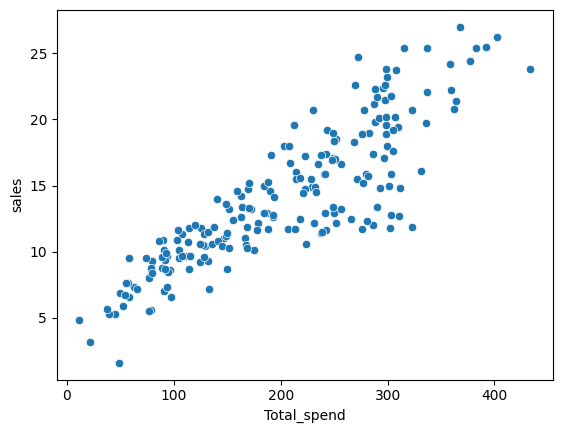

In [34]:
sns.scatterplot(data=df,x='Total_spend',y='sales')

<Axes: xlabel='Total_spend', ylabel='sales'>

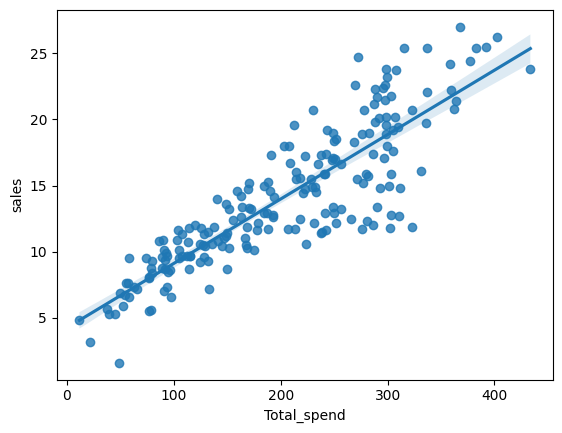

In [35]:
sns.regplot(df,x='Total_spend',y='sales')

In [36]:
X=df['Total_spend']
y=df['sales']

In [37]:
np.polyfit(X,y,deg=1) # Returns b1 and b0 respectively for y=b0+b1X

array([0.04868788, 4.24302822])

In [38]:
potential_spend=np.linspace(0,500,100)

In [39]:
# Calculate predicted sales for each of the potential_spend values
predicted_sales=4.24302822+0.04868788*potential_spend # thse are the coeff value found by using np.polyfit(X,y,deg-1)

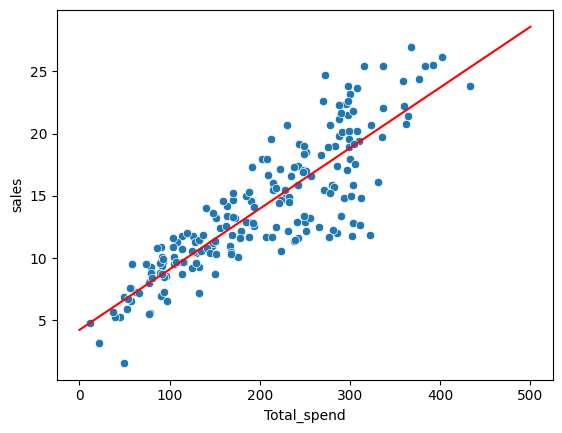

In [40]:
# Let's plot this line together with the previous scatter plot
sns.scatterplot(data=df,x='Total_spend',y='sales')
plt.plot(potential_spend,predicted_sales,color='red')

This is good, but we cannot evaluate a prediction, that is, say for a Total_spend of 200, we can predict the sales amount, however we cannot understand how accurate the prediction is from this method.

Before moving to evaluation of model, we can explore polynomial fit using `np.polyfit(X,y,deg=3)`. Here, this will give me an array of $\beta_3,\beta_2,\beta_1 and \beta_0$  
where $y=\beta_3x^3+\beta_2x^2+\beta_1x+\beta_0$



In [41]:
np.polyfit(X,y,deg=3)

array([ 3.07615033e-07, -1.89392449e-04,  8.20886302e-02,  2.70495053e+00])

In [42]:
# Generating potential Total_spend
pot_spend=np.linspace(0,500,100)

# For the potential total spend predicted sales
pred_sales=3.07615033e-07*pot_spend**3-1.89392449e-04*pot_spend**2+8.20886302e-02*pot_spend+2.70495053e+00

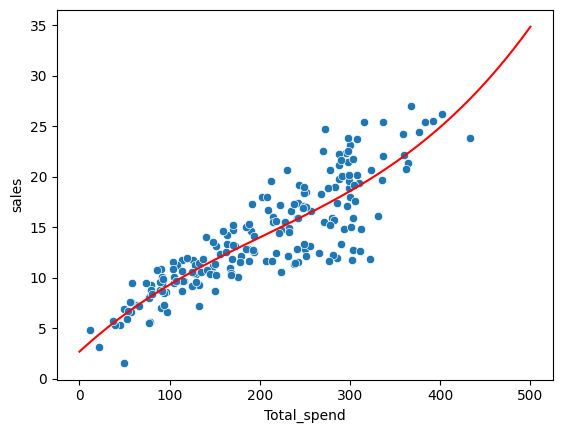

In [43]:
# Let's plot this line together with the previous scatter plot
sns.scatterplot(data=df,x='Total_spend',y='sales')
plt.plot(pot_spend,pred_sales,color='red')

Again the same question arises, how do you determine that this line is better/worse fit than the previous one? How can we evaluate our model?

**Here comes Scikit-Learn train test Split**

# Scikit-Learn train-test  split

* Previously we have explored 'Is there a relationship between **total advertising spend** and **sales**'?
* Now we want to expand this to "What is the relationship betweeb **each advertising channel(TV,Radio,Newspaper)** and **sales** 

In [44]:
df=pd.read_csv("./data/Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Before moving to more depth,let's actually explore each channels' relationship with advertising spend.y

Text(0.5, 1.0, 'Newspaper Spend')

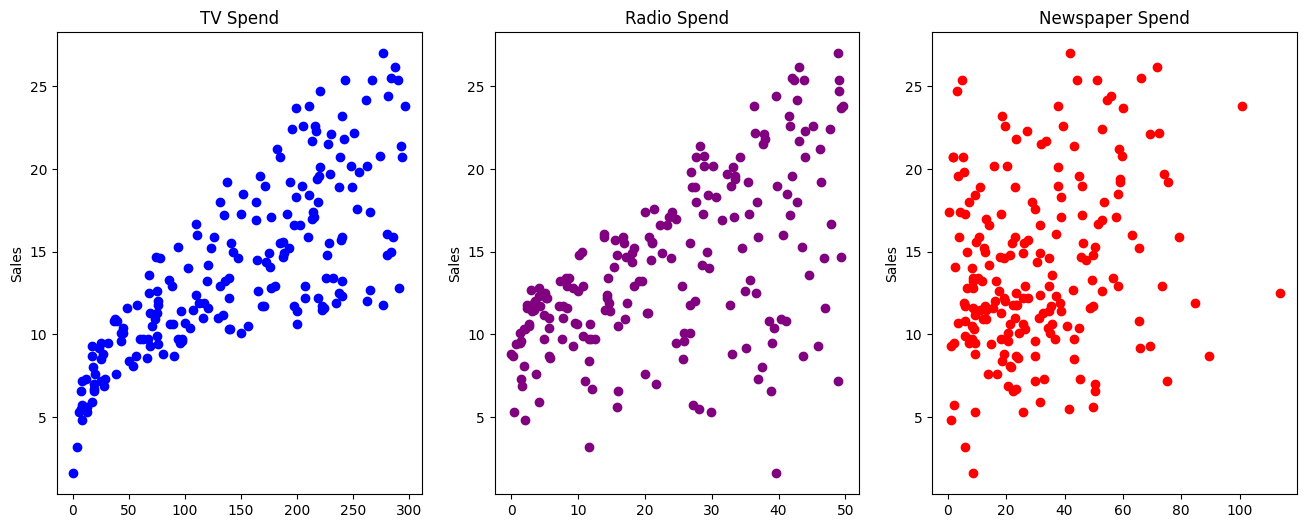

In [45]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o',color='blue')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'],df['sales'],'o',color='purple')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Spend')

axes[2].plot(df['newspaper'],df['sales'],'o',color='red')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')


Here we can see for TV and Radio spend as we increase the advertising expenses sales also increases. However for Newspaper, the trend is somewhat ambiguous.

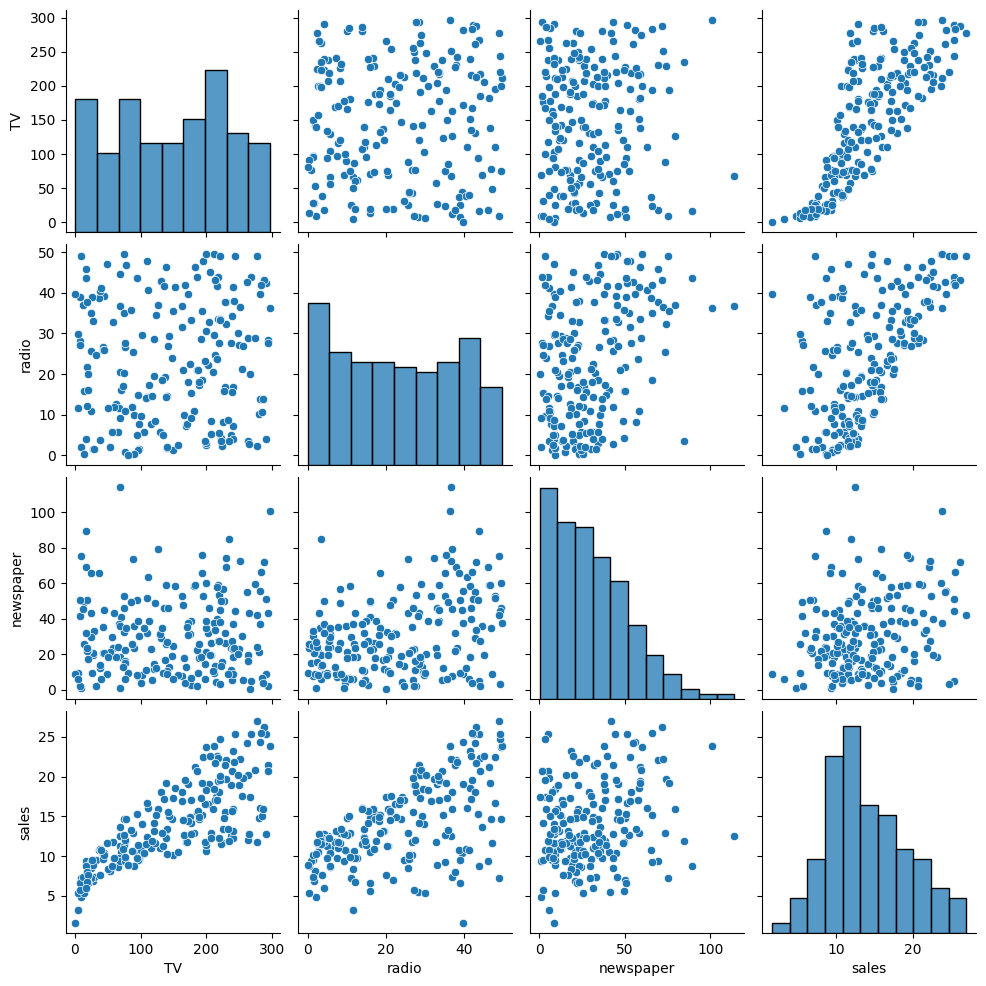

In [46]:
sns.pairplot(df)

In [47]:
# Seperating features and labels
X=df.drop('sales',axis=1)
y=df['sales']

In [48]:
from sklearn.model_selection import train_test_split


In [49]:
# Train-test  split using scikit-learn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [50]:
print(len(df))
print(len(X_train))
print(len(X_test))

200
140
60


In [51]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

In [52]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.04, 0.19,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','radio','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


## Performance Evaluation

Let's discuss some of the most common evaluation metrics for evaluation
* Mean Absolute Error(MAE)
* Mean Squared Error(MSE)
* Roor Mean Squared Error(RMSE)

 ### <u>Mean Absolute Error</u> 

 * **This is the mean of absolute value of errors**:

 $1/n\sum_{i=1}^n|y_i-\hat{y}_i|$

However, MAE won't punish large errors.

## <u>Mean Squared Errors</u>

* Larger errors are punished more than with MAE, making MSE more popular:

$1/n\sum_{i=1}^n(y_i-\hat{y}_i)^2$

Here's the issue is MSE is in different unit than y

## <u> Root Mean Squared Error</u>
Root of MSE:

$\sqrt(1/n\sum_{i=1}^n(y_i-\hat{y}_i)^2)$
 

So, going to back to coding

In [53]:
X_test.head()

,TV,radio,newspaper
37,74.7,49.4,45.7
109,255.4,26.9,5.5
31,112.9,17.4,38.6
89,109.8,47.8,51.4
66,31.5,24.6,2.2


In [54]:
y_test.head() #observed values

37     14.7
109    19.8
31     11.9
89     16.7
66      9.5
Name: sales, dtype: float64

In [55]:
y_pred=model.predict(X_test) # Test prediction
y_pred

array([15.74131332, 19.61062568, 11.44888935, 17.00819787,  9.17285676,
        7.01248287, 20.28992463, 17.29953992,  9.77584467, 19.22194224,
       12.40503154, 13.89234998, 13.72541098, 21.28794031, 18.42456638,
        9.98198406, 15.55228966,  7.68913693,  7.55614992, 20.40311209,
        7.79215204, 18.24214098, 24.68631904, 22.82199068,  7.97962085,
       12.65207264, 21.46925937,  8.05228573, 12.42315981, 12.50719678,
       10.77757812, 19.24460093, 10.070269  ,  6.70779999, 17.31492147,
        7.76764327,  9.25393336,  8.27834697, 10.58105585, 10.63591128,
       13.01002595,  9.77192057, 10.21469861,  8.04572042, 11.5671075 ,
       10.08368001,  8.99806574, 16.25388914, 13.23942315, 20.81493419,
       12.49727439, 13.96615898, 17.56285075, 11.14537013, 12.56261468,
        5.50870279, 23.29465134, 12.62409688, 18.77399978, 15.18785675])

In [56]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error

In [57]:
df['sales'].mean() # mean of sales

np.float64(14.0225)

<Axes: xlabel='sales', ylabel='Count'>

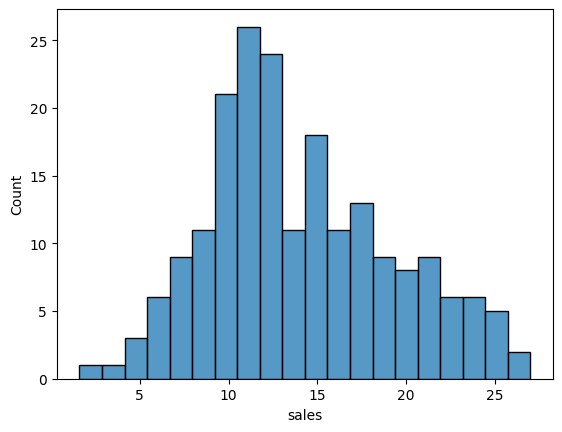

In [58]:
sns.histplot(data=df,x='sales',bins=20) # Distribution of sales

In [59]:
print(f"MAE:{mean_absolute_error(y_test,y_pred)}")
print(f'MSE:{mean_squared_error(y_test,y_pred)}')
print(f"RMSE:{root_mean_squared_error(y_test,y_pred)}")

MAE:1.2137457736144805
MSE:2.298716697886378
RMSE:1.5161519375993877


Often for Linear Regression it is a good idea to separately evaluate residulas $(y-\hat{y})$ and not just calculate metrics(e.g. RMSE)


There's these 4 different sets of datapoints, called Anscombe's Quartet. Each of these data points have similar linear regression line and pretty similar summary statistics

In [60]:
quartet1=pd.read_csv("./data/anscombes_quartet1.csv")
quartet2=pd.read_csv("./data/anscombes_quartet2.csv")
quartet3=pd.read_csv("./data/anscombes_quartet3.csv")
quartet4=pd.read_csv("./data/anscombes_quartet4.csv")



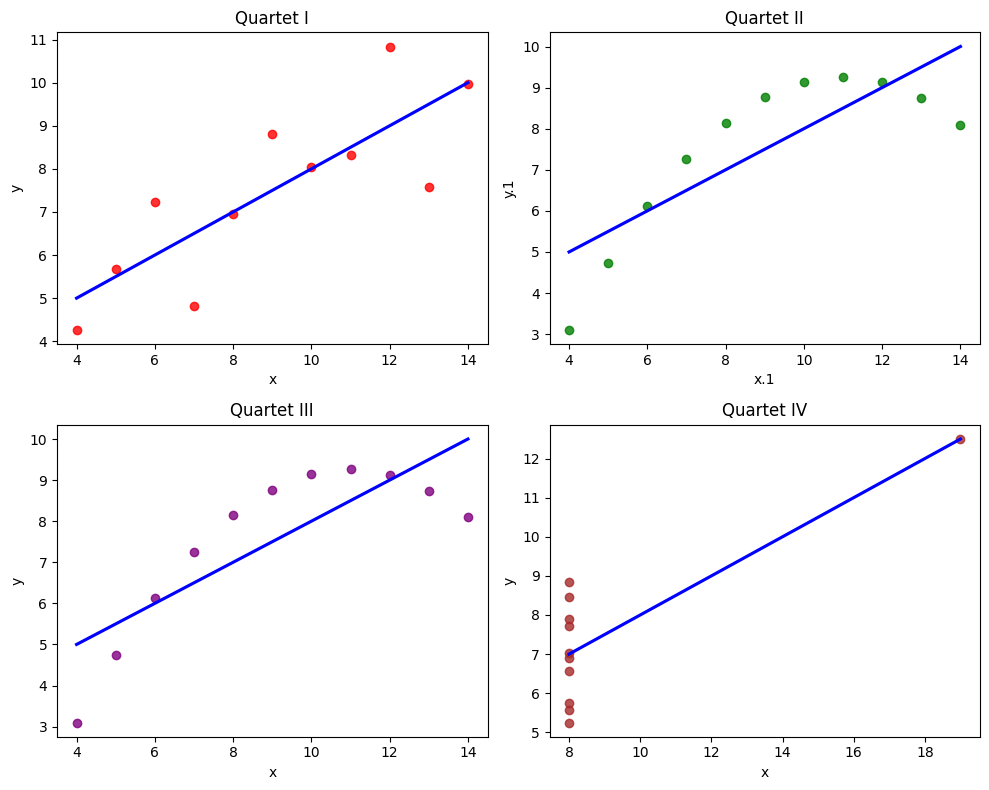

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Anscombe's Quartet I
sns.regplot(
    x='x', y='y', data=quartet1,
    ax=axes[0][0],
    color='red',
    ci=None,
    line_kws={'color': 'blue'}
)
axes[0][0].set_title("Quartet I")

# Anscombe's Quartet II
sns.regplot(
    x='x.1', y='y.1', data=quartet2,
    ax=axes[0][1],
    color='green',
    ci=None,
    line_kws={'color': 'blue'}
)
axes[0][1].set_title("Quartet II")

# Anscombe's Quartet III
sns.regplot(
    x='x', y='y', data=quartet3,
    ax=axes[1][0],
    color='purple',
    ci=None,
    line_kws={'color': 'blue'}
)
axes[1][0].set_title("Quartet III")

# Anscombe's Quartet IV
sns.regplot(
    x='x', y='y', data=quartet4,
    ax=axes[1][1],
    color='brown',
    ci=None,
    line_kws={'color': 'blue'}
)
axes[1][1].set_title("Quartet IV")

plt.tight_layout()
plt.show()

Though for each of these datasets linear regression line is the same along with similar summary statistics, we can see when plotted, only for quartet 1 linear regression is valid.

However, this is easy to visualise as here we are dealing with only one feature. What about while using multiple features! How can we see the discrepancy when we have multiple features! **Well we cannot!**

<span style="color:red">**However, what we could do is plot residual errors against true y values**</span>

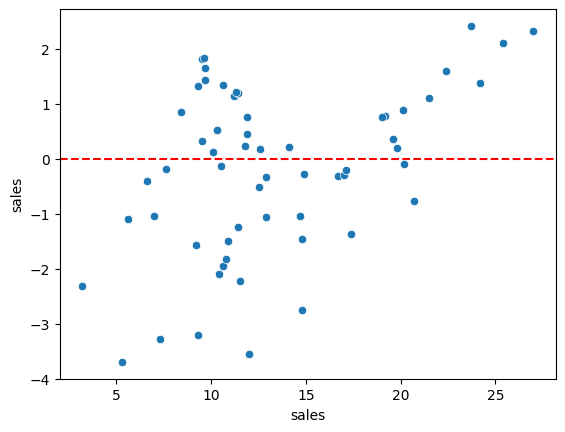

In [62]:
# Plotting the residula for df
test_residuals=y_test-y_pred
sns.scatterplot(x=y_test,y=test_residuals)
plt.axhline(y=0,color="red",ls="--")

If there was any particular pattern noted in this residul plot, then there might be something funky going on undeerneath, and linear regression probably won't be a perfect model for the given dataset.


<Axes: xlabel='sales', ylabel='Count'>

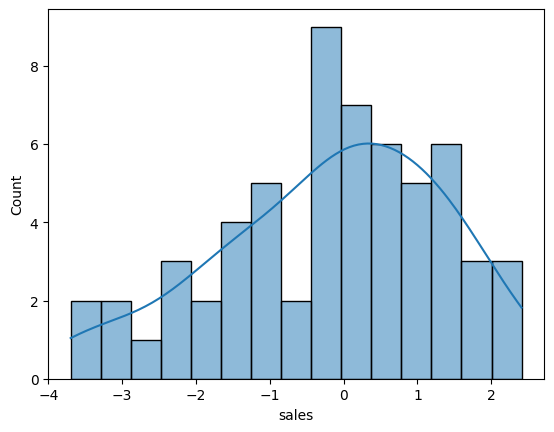

In [63]:
sns.histplot(test_residuals,bins=15,kde=True)

To see my residula distribution is normal or normality is a reasonable approximation, we plot normal-probability plot

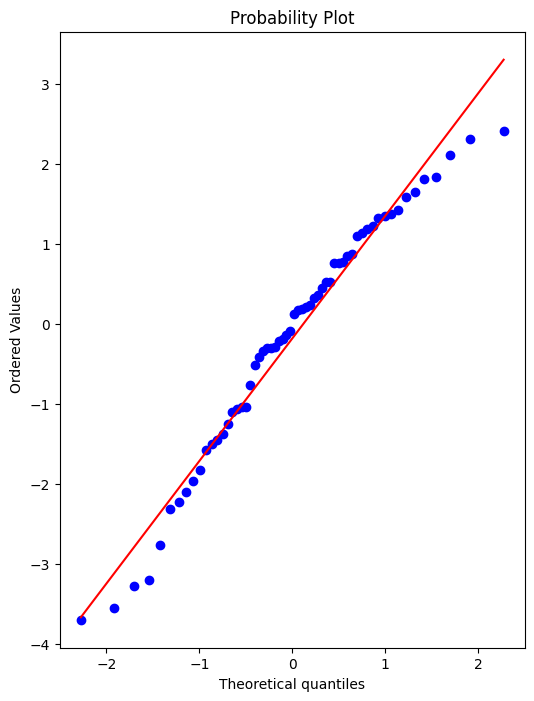

In [64]:
import scipy as sp
fig,ax=plt.subplots(figsize=(6,8),dpi=100)
# Probplot returns the raw values if needed 
# We justt want to see the plot, so we assign these values to _
_=sp.stats.probplot(test_residuals,plot=ax)

In [65]:
final_model=LinearRegression()
final_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05, 0.19,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','radio','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.939
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [66]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

Notice that beta coeff for newspaper spend is negative small number. Which was quite visible when we plotted the scatter plots for sales vs different channel spend.

In [67]:
y_hat=final_model.predict(X)

Text(0.5, 1.0, 'Newspaper Spend')

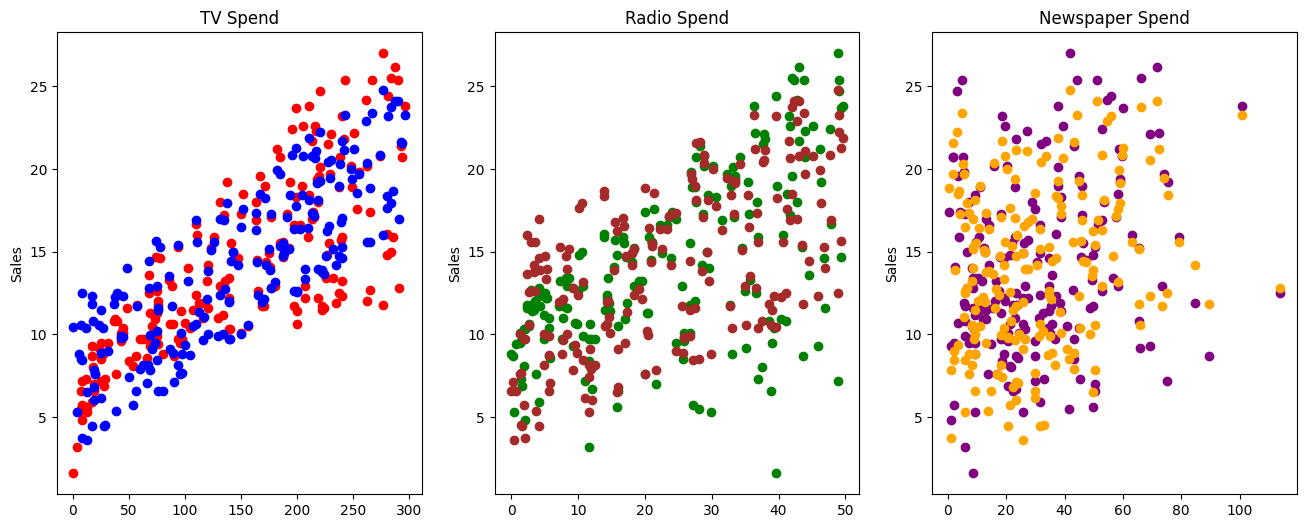

In [68]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o',color='red')
axes[0].plot(df['TV'],y_hat,'o',color='blue')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'],df['sales'],'o',color='green')
axes[1].plot(df['radio'],y_hat,'o',color='brown')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Spend')


axes[2].plot(df['newspaper'],df['sales'],'o',color='purple')
axes[2].plot(df['newspaper'],y_hat,'o',color='orange')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')





In [69]:
# Saving and loading a model
from joblib import dump,load

# Saving the final model
dump(final_model,'final_sales_model.joblib')

['final_sales_model.joblib']

In [70]:
# Loading the finak_sales_model.joblib
loaded_model=load('final_sales_model.joblib')

In [71]:
loaded_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [72]:
# Predicting a sales value for some advertising campaign with the loaded model
campaign=[[149,22,12]]

In [73]:
loaded_model.predict(campaign)

c:\Users\apara\Desktop\Python for ML\6.Linear_Regression\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032])

## Polynomial Regression

There are two issues that polynomial regression will address fo us:
1. Non-linear feature relationship to label
2. Interaction term between features

In [74]:
from sklearn.preprocessing import PolynomialFeatures

In [75]:
df=pd.read_csv("./data/Advertising.csv")


In [76]:
X=df.drop('sales',axis=1)
y=df['sales']

In [77]:
poly_converter=PolynomialFeatures(degree=2,interaction_only=False,include_bias=False)



In [78]:
X.shape

(200, 3)

In [79]:
poly_feature=poly_converter.fit_transform(X)

In [80]:
poly_feature.shape

(200, 9)

In [81]:
from sklearn.model_selection import train_test_split


In [82]:
X_train, X_test, y_train, y_test = train_test_split(poly_feature, y, test_size=0.3, random_state=101)

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
model=LinearRegression()

In [85]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.05, 0.01, 0.01,..., 0. , 0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.126
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[304692.02, 51558.83, 29086.88,..., 226.23, 61.34, 40.79]"


In [86]:
y_pred=model.predict(X_test)

In [87]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error

In [88]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)
print(f"MAE={MAE}\nMSE={MSE}\nRMSE={RMSE}")

MAE=0.4896798044803672
MSE=0.44175055104035066
RMSE=0.6646431757269089


But while chosing degree of polynomial, we decided to go with a fixed polynomial degree of 2. How do we know that's the best fit! Well....we don't know if that's the best! We should check and verify for multiple polynomial degreee. In comes the infamous bias-variance trade off! Now, what is that!

### **BIAS VARIANCE TRADEOFF**
* We have seen that a higher order polynomial model performs significantly better than a standard linear regression model.
* But the question is-How can we choose the optimal degree for polynomial? 
* What trade-offs do we have to consider as we increase model complexity!
* Bias-Variance tradeoff is the answer. Extremee bias or extreme variance both lead to bad models.


We can visualize this effect by considering a model that underfits(high bias) or a model that overfits(high variance).

Let's start with a model that overfits to a dataset.

**<u>Overfitting</u>**
* This model fits too much to the noise from the data 
* This result in low error in training data but high error on training/validation data


**<u>Underfitting</u>**
* Model does not capture the underlying trend in data and does not fit the data well enough
* Low variance but high bias
* Underfitting is often result of an excessively simple model


To find the optimal degree of polynomial for polynomial regression, we have to visualize error vs model complexity(for polynomial regression it is degree of polynomial) for both test and train dataset. Ideally there will be degree of polynomial after which error for test data will shoot upward.

In [89]:
df=pd.read_csv("./data/Advertising.csv")

X=df.drop("sales",axis=1)
y=df["sales"]

In [90]:
RMSE_TRAIN=[]
RMSE_TEST=[]

MAE_TEST=[]
MAE_TRAIN=[]
for i in range(1,10):

    # Create the different order polynoial
    poly_converter=PolynomialFeatures(degree=i,include_bias=False)
    poly_features=poly_converter.fit_transform(X)

    # Splitting poly features into tran/test
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

    # Fit on train
    model=LinearRegression()
    model.fit(X_train,y_train)

    # Store the RMSE AND MAE for the train and test data
    y_test_pred=model.predict(X_test)
    y_train_pred=model.predict(X_train)

    mae_test=mean_absolute_error(y_test,y_test_pred)
    mae_train=mean_absolute_error(y_train,y_train_pred)
    MAE_TEST.append(mae_test)
    MAE_TRAIN.append(mae_train)

    rmse_test=root_mean_squared_error(y_test,y_test_pred)
    rmse_train=root_mean_squared_error(y_train,y_train_pred)
    RMSE_TEST.append(rmse_test)
    RMSE_TRAIN.append(rmse_train)
    


In [91]:
# Best degree of polynomial
np.argmin(RMSE_TEST)+1

np.int64(2)

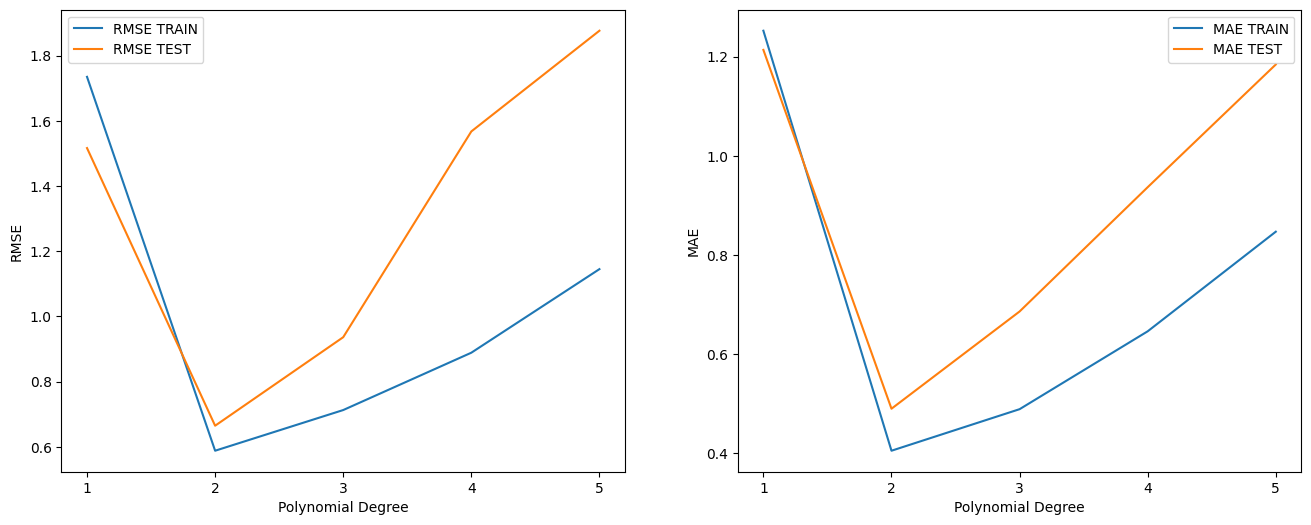

In [92]:
fig,axes=plt.subplots(nrows=1,ncols=2,figsize=(16,6))

axes[0].plot(range(1,6),RMSE_TRAIN[:5],label='RMSE TRAIN')
axes[0].plot(range(1,6),RMSE_TEST[:5],label='RMSE TEST')
axes[0].legend()
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("RMSE")
axes[0].set_xticks([1,2,3,4,5])

axes[1].plot(range(1,6),MAE_TRAIN[:5],label='MAE TRAIN')
axes[1].plot(range(1,6),MAE_TEST[:5],label='MAE TEST')
axes[1].legend()
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("MAE")
axes[1].set_xticks([1,2,3,4,5])

So here, we will proceed with polynomial regression model with degree=2, as there rmse is minimum 

# Regularization in Linear Regression: Ridge, Lasso, and Elastic Net

## Why Do We Need Regularization?

In Ordinary Least Squares (OLS), we minimize the Sum of Squared Errors (SSE):

$$
SSE=\sum_{i=1}^{n}(y_i-\hat y_i)^2
$$

or equivalently the cost function:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

where

$$
\hat y
=
\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p
$$

OLS focuses entirely on minimizing prediction error on the training data.

As model complexity increases, OLS may begin fitting noise rather than the true signal. This phenomenon is known as **overfitting**.

Overfitting often leads to:

- Large coefficient values
- High variance
- Poor generalization to unseen data

Regularization combats overfitting by penalizing large coefficient values.

---

# General Regularization Framework

Instead of minimizing only the loss function, regularization adds a penalty term:

$$
\text{Cost Function}
=
\text{Loss}
+
\text{Penalty}
$$

For linear regression:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\text{Penalty}
$$

The penalty discourages excessively large coefficients.

A hyperparameter controls the strength of the penalty:

$$
\lambda \ge 0
$$

where:

- $\lambda = 0$ → OLS
- Larger $\lambda$ → stronger regularization

Typically, the intercept $\beta_0$ is not penalized.

---

# Ridge Regression (L2 Regularization)

Ridge Regression adds the squared magnitude of coefficients as a penalty.

## Cost Function

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

Expanded:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
(\beta_1^2+\beta_2^2+\cdots+\beta_p^2)
$$

---

## L2 Norm

The Ridge penalty is based on the L2 norm:

$$
||\beta||_2
=
\sqrt{
\beta_1^2+\beta_2^2+\cdots+\beta_p^2
}
$$

Since the square root does not affect optimization, Ridge uses:

$$
||\beta||_2^2
=
\sum_{j=1}^{p}\beta_j^2
$$

---

## Effect of Ridge Regression

Ridge:

- Shrinks coefficients toward zero
- Rarely makes coefficients exactly zero
- Retains all features
- Reduces variance
- Handles multicollinearity effectively

As $\lambda$ increases:

$$
\beta_j \rightarrow 0
$$

but generally never becomes exactly zero.

---

## Matrix Solution for Ridge

Recall the OLS solution:

$$
\hat\beta
=
(X^TX)^{-1}X^Ty
$$

Ridge modifies it to:

$$
\hat\beta_{ridge}
=
(X^TX+\lambda I)^{-1}X^Ty
$$

where:

- $I$ is the identity matrix
- $\lambda I$ stabilizes matrix inversion

---

# Lasso Regression (L1 Regularization)

Lasso Regression adds the absolute values of coefficients as a penalty.

## Cost Function

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

Expanded:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
(|\beta_1|+|\beta_2|+\cdots+|\beta_p|)
$$

---

## L1 Norm

The L1 norm is:

$$
||\beta||_1
=
\sum_{j=1}^{p}
|\beta_j|
$$

---

## Effect of Lasso Regression

Lasso:

- Shrinks coefficients
- Can force coefficients exactly to zero
- Performs automatic feature selection
- Produces sparse models

Example:

Before regularization:

$$
\beta=(5.2,2.7,0.8,1.1)
$$

After Lasso:

$$
\beta=(4.1,0,0,0.9)
$$

Features with zero coefficients are effectively removed.

---

## Why Does Lasso Produce Zero Coefficients?

The L1 penalty has sharp corners at zero.

During optimization, coefficients can land exactly on these corners:

$$
\beta_j = 0
$$

This property enables feature selection.

---

# Elastic Net Regression

Elastic Net combines Ridge and Lasso penalties.

It inherits:

- Feature selection from Lasso
- Stability from Ridge

---

## Cost Function

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
\left[
(1-\alpha)
\sum_{j=1}^{p}\beta_j^2
+
\alpha
\sum_{j=1}^{p}
|\beta_j|
\right]
$$

where:

- $\lambda$ controls overall penalty strength
- $\alpha$ controls the balance between L1 and L2 penalties

---

## Special Cases

### Ridge Regression

When:

$$
\alpha = 0
$$

Elastic Net becomes:

$$
J=
Loss+\lambda\sum\beta_j^2
$$

---

### Lasso Regression

When:

$$
\alpha = 1
$$

Elastic Net becomes:

$$
J=
Loss+\lambda\sum|\beta_j|
$$

---

### Elastic Net

When:

$$
0 < \alpha < 1
$$

both penalties are active.

---

# Geometric Interpretation

## OLS

Minimizes:

$$
SSE
$$

with no restriction on coefficient size.

---

## Ridge Constraint

$$
\sum\beta_j^2 \le t
$$

The feasible region is circular (or spherical in higher dimensions).

---

## Lasso Constraint

$$
\sum|\beta_j|\le t
$$

The feasible region is diamond-shaped.

The corners make exact zero coefficients likely.

---

## Elastic Net Constraint

Combines both L1 and L2 constraints, balancing shrinkage and feature selection.

---

# Comparison

| Property | Ridge | Lasso | Elastic Net |
|-----------|--------|--------|-------------|
| Penalty | L2 | L1 | L1 + L2 |
| Shrinks Coefficients | Yes | Yes | Yes |
| Produces Exact Zeroes | No | Yes | Yes |
| Feature Selection | No | Yes | Yes |
| Handles Multicollinearity | Excellent | Moderate | Excellent |
| Sparse Model | No | Yes | Yes |

---

# Practical Guidelines

## Use Ridge When

- Most features are useful
- Multicollinearity exists
- Prediction accuracy is the primary objective

---

## Use Lasso When

- Many features may be irrelevant
- Feature selection is desired
- Interpretability is important

---

## Use Elastic Net When

- Features are highly correlated
- Feature selection is desired
- Lasso becomes unstable

Elastic Net is often preferred for high-dimensional datasets.

---

# Summary

### OLS

$$
\sum(y_i-\hat y_i)^2
$$

### Ridge Regression

$$
\sum(y_i-\hat y_i)^2
+
\lambda\sum\beta_j^2
$$

### Lasso Regression

$$
\sum(y_i-\hat y_i)^2
+
\lambda\sum|\beta_j|
$$

### Elastic Net Regression

$$
\sum(y_i-\hat y_i)^2
+
\lambda
\left[
(1-\alpha)\sum\beta_j^2
+
\alpha\sum|\beta_j|
\right]
$$

Regularization introduces bias in exchange for reducing variance, often resulting in improved performance on unseen data.

# Feature Scaling in Machine Learning

## Why Do We Need Feature Scaling?

Machine learning algorithms often work with features that have different units and magnitudes.

Consider the following dataset:

| House Size (sq.ft.) | Number of Bedrooms |
|--------------------|--------------------|
| 2500 | 2 |
| 3200 | 3 |
| 4000 | 4 |

Notice:

- House Size ranges from thousands.
- Bedrooms range from single digits.

Although both are valid predictors, their scales differ significantly.

Many machine learning algorithms are sensitive to feature magnitude.

Without feature scaling:

- Features with larger numerical values can dominate the learning process.
- Gradient descent may converge slowly.
- Distance-based algorithms become biased toward large-scale features.
- Regularization penalties become unfair.

---

# Which Algorithms Need Feature Scaling?

## Usually Need Scaling

- Linear Regression (Gradient Descent)
- Logistic Regression
- Ridge Regression
- Lasso Regression
- Elastic Net
- Support Vector Machines (SVM)
- K-Nearest Neighbors (KNN)
- K-Means Clustering
- Principal Component Analysis (PCA)
- Neural Networks

---

## Usually Do Not Need Scaling

Tree-based algorithms split based on feature ordering rather than distance.

Examples:

- Decision Trees
- Random Forest
- XGBoost
- LightGBM
- CatBoost

---

# Feature Scaling and Gradient Descent

Suppose our cost function is:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

For two features:

$$
\hat y
=
\beta_0+\beta_1x_1+\beta_2x_2
$$

Assume:

$$
x_1 \in [0,10000]
$$

and

$$
x_2 \in [0,10]
$$

The cost function becomes elongated rather than circular.

Gradient descent then follows a zig-zag path toward the minimum.

This leads to:

- Slow convergence
- More iterations
- Difficulty choosing learning rates

Feature scaling makes the cost surface more symmetric, allowing gradient descent to converge much faster.

---

# Standardization (Z-Score Scaling)

Standardization transforms a feature so that:

- Mean = 0
- Standard Deviation = 1

---

## Formula

For each observation:

$$
x_{scaled}
=
\frac{x-\bar{x}}{s}
$$

where:

- $\bar{x}$ = feature mean
- $s$ = feature standard deviation

---

## Sample Mean

$$
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n}
x_i
$$

---

## Sample Standard Deviation

$$
s
=
\sqrt{
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}
{n-1}
}
$$

---

## Example

Feature:

$$
(10,20,30)
$$

Mean:

$$
\bar{x}
=
\frac{10+20+30}{3}
=
20
$$

Standard deviation:

$$
s=10
$$

Scaled values:

$$
\left(
\frac{10-20}{10},
\frac{20-20}{10},
\frac{30-20}{10}
\right)
=
(-1,0,1)
$$

---

# Properties of Standardization

After transformation:

$$
\text{Mean} = 0
$$

$$
\text{Standard Deviation} = 1
$$

The data is centered and scaled.

---

# Min-Max Scaling (Normalization)

Min-Max Scaling transforms data into a fixed range.

Most commonly:

$$
[0,1]
$$

---

## Formula

$$
x_{scaled}
=
\frac{x-x_{min}}
{x_{max}-x_{min}}
$$

---

## Example

Feature:

$$
(10,20,30)
$$

Minimum:

$$
x_{min}=10
$$

Maximum:

$$
x_{max}=30
$$

Scaled values:

$$
\left(
0,
0.5,
1
\right)
$$

---

# Properties of Min-Max Scaling

After transformation:

$$
x_{min}=0
$$

$$
x_{max}=1
$$

All observations lie between 0 and 1.

---

# Robust Scaling

Standardization uses mean and standard deviation.

These statistics are sensitive to outliers.

Robust Scaling uses:

- Median
- Interquartile Range (IQR)

making it resistant to extreme values.

---

## Formula

$$
x_{scaled}
=
\frac{x-\text{Median}}
{\text{IQR}}
$$

where:

$$
IQR = Q_3 - Q_1
$$

---

## Quartiles

### First Quartile

$$
Q_1
$$

25th percentile

### Third Quartile

$$
Q_3
$$

75th percentile

---

# Why Robust Scaling Works

Suppose income data contains:

$$
(30,35,40,45,5000)
$$

The mean becomes heavily distorted.

The median remains relatively stable.

Therefore Robust Scaling handles outliers better than Standardization.

---

# Feature Scaling and Regularization

Consider Ridge Regression:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

and Lasso Regression:

$$
J(\beta)
=
\frac{1}{2n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
+
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

The penalty is applied directly to coefficient values.

If features are on different scales:

| Feature | Scale |
|----------|--------|
| Income | 100000 |
| Age | 20-60 |

then coefficients become incomparable.

The regularization penalty becomes unfair.

Feature scaling ensures every feature is penalized equally.

---

# Important Rule: Train-Test Split First

Always split data before scaling.

Correct workflow:

1. Train-Test Split
2. Fit scaler on training data
3. Transform training data
4. Transform test data using the same scaler

---

## Correct Procedure

Training data:

$$
\mu_{train}
,\;
\sigma_{train}
$$

are calculated.

Then:

$$
x_{test}
=
\frac{x_{test}-\mu_{train}}
{\sigma_{train}}
$$

---

## Why?

Using the test set to calculate scaling parameters leaks information from the future.

This is called:

**Data Leakage**

and leads to overly optimistic performance estimates.

---

# Comparison of Scaling Methods

| Method | Formula | Sensitive to Outliers |
|----------|----------|----------|
| Standardization | $(x-\bar{x})/s$ | Yes |
| Min-Max Scaling | $(x-x_{min})/(x_{max}-x_{min})$ | Yes |
| Robust Scaling | $(x-\text{Median})/IQR$ | No |

---

# When to Use Which?

### Standardization

Use when:

- Data is approximately normally distributed
- Using linear models
- Using logistic regression
- Using PCA
- Using neural networks

---

### Min-Max Scaling

Use when:

- Values need to stay within a fixed range
- Neural networks require bounded inputs

---

### Robust Scaling

Use when:

- Significant outliers exist
- Median is more representative than mean

---

# Summary

Feature scaling transforms variables onto comparable scales.

The three most common methods are:

### Standardization

$$
x_{scaled}
=
\frac{x-\bar{x}}
{s}
$$

Mean becomes 0 and standard deviation becomes 1.

---

### Min-Max Scaling

$$
x_{scaled}
=
\frac{x-x_{min}}
{x_{max}-x_{min}}
$$

Values are transformed to the interval:

$$
[0,1]
$$

---

### Robust Scaling

$$
x_{scaled}
=
\frac{x-\text{Median}}
{IQR}
$$

Uses median and interquartile range, making it resistant to outliers.

Feature scaling improves optimization, ensures fair regularization, and is essential for many machine learning algorithms.

# Cross Validation in Machine Learning

## Why Do We Need Cross Validation?

Suppose we train a model on a dataset and evaluate it using the same data.

Example:

1. Train on Dataset
2. Test on Dataset

This often produces unrealistically good performance because the model has already seen the data.

The model may memorize patterns specific to the training set rather than learn generalizable relationships.

This phenomenon is called **overfitting**.

To estimate how well a model will perform on unseen data, we need a more reliable evaluation strategy.

Cross Validation provides such a strategy.

---

# The Generalization Problem

Our ultimate goal is not to perform well on training data.

Instead, we want the model to perform well on new, unseen observations.

Conceptually:

$$
\text{Training Error}
\neq
\text{Future Error}
$$

A model with very low training error can still have poor predictive performance on unseen data.

Cross Validation helps estimate future performance.

---

# Hold-Out Validation

The simplest approach is a Train-Test Split.

Example:

- 80% Training Data
- 20% Testing Data

Workflow:

1. Train model on training set
2. Predict on test set
3. Calculate evaluation metric

Example:

$$
R^2
=
0.85
$$

or

$$
RMSE
=
3.2
$$

---

## Limitation of Train-Test Split

The performance estimate depends heavily on the random split.

Example:

### Split A

RMSE = 2.8

### Split B

RMSE = 4.5

### Split C

RMSE = 3.6

Different splits can produce different results.

This creates uncertainty regarding true model performance.

Cross Validation reduces this uncertainty.

---

# K-Fold Cross Validation

K-Fold Cross Validation divides the dataset into \(K\) equal-sized folds.

Common choice:

$$
K=5
$$

or

$$
K=10
$$

---

## Example: 5-Fold Cross Validation

Suppose:

$$
n=100
$$

observations.

Split into:

| Fold | Size |
|--------|--------|
| Fold 1 | 20 |
| Fold 2 | 20 |
| Fold 3 | 20 |
| Fold 4 | 20 |
| Fold 5 | 20 |

---

## Iteration 1

Train on:

- Fold 2
- Fold 3
- Fold 4
- Fold 5

Validate on:

- Fold 1

---

## Iteration 2

Train on:

- Fold 1
- Fold 3
- Fold 4
- Fold 5

Validate on:

- Fold 2

---

Continue until every fold has served as the validation set exactly once.

---

# Number of Models Trained

For \(K\) folds:

$$
K
$$

separate models are trained.

Example:

### 5-Fold CV

$$
5
$$

models

### 10-Fold CV

$$
10
$$

models

---

# Cross Validation Score

Suppose 5-fold validation produces:

| Fold | RMSE |
|--------|--------|
| 1 | 3.1 |
| 2 | 2.9 |
| 3 | 3.4 |
| 4 | 3.0 |
| 5 | 3.2 |

Average RMSE:

$$
\text{CV Score}
=
\frac{3.1+2.9+3.4+3.0+3.2}{5}
$$

$$
=
3.12
$$

This average provides a more stable estimate of model performance.

---

# Mathematical Representation

Let:

$$
M_i
$$

be the validation metric for fold \(i\).

Then the cross-validation score is:

$$
CV
=
\frac{1}{K}
\sum_{i=1}^{K}
M_i
$$

---

# Why Cross Validation Works

Every observation is used:

### For Training

$$
K-1
$$

times

### For Validation

$$
1
$$

time

As a result:

- Better use of available data
- Lower variance estimate
- More reliable performance evaluation

---

# Bias-Variance Tradeoff in K-Folds

### Small K

Example:

$$
K=2
$$

Advantages:

- Faster

Disadvantages:

- Higher bias
- Less reliable estimate

---

### Large K

Example:

$$
K=10
$$

Advantages:

- Lower bias
- More reliable estimate

Disadvantages:

- More computationally expensive

---

# Leave-One-Out Cross Validation (LOOCV)

Extreme case:

$$
K=n
$$

Each fold contains exactly one observation.

---

## Procedure

For observation \(i\):

- Train on \(n-1\) observations
- Validate on observation \(i\)

Repeat for every observation.

---

## Number of Models

$$
n
$$

models

For a dataset with:

$$
n=1000
$$

LOOCV requires:

$$
1000
$$

separate model fits.

---

## Advantages

- Uses almost all data for training
- Very low bias

---

## Disadvantages

- Computationally expensive
- High variance estimate

---

# Stratified K-Fold Cross Validation

Used mainly for classification.

Problem:

Suppose:

| Class | Percentage |
|----------|----------|
| Class A | 95% |
| Class B | 5% |

Random folds may contain almost no minority class observations.

---

## Solution

Stratified K-Fold preserves class proportions in every fold.

Example:

Overall dataset:

| Class | Percentage |
|----------|----------|
| A | 95% |
| B | 5% |

Each fold:

| Class | Percentage |
|----------|----------|
| A | 95% |
| B | 5% |

This produces more reliable classification metrics.

---

# Cross Validation for Hyperparameter Tuning

Cross Validation is heavily used for selecting hyperparameters.

Example:

Ridge Regression:

$$
\lambda
=
0.001
$$

$$
\lambda
=
0.01
$$

$$
\lambda
=
0.1
$$

$$
\lambda
=
1
$$

For each value:

1. Perform K-Fold Cross Validation
2. Calculate average validation score
3. Choose the best hyperparameter

---

# Grid Search with Cross Validation

Suppose:

| Parameter | Values |
|------------|------------|
| Alpha | 0.01, 0.1, 1, 10 |
| Degree | 1, 2, 3 |

Number of combinations:

$$
4 \times 3
=
12
$$

If:

$$
K=5
$$

then:

$$
12 \times 5
=
60
$$

models are trained.

The combination with the best cross-validation score is selected.

---

# Nested Cross Validation

Used when hyperparameter tuning itself needs unbiased evaluation.

Outer Loop:

- Evaluates performance

Inner Loop:

- Tunes hyperparameters

This provides the least biased estimate of model performance.

---

# Cross Validation Workflow

For model development:

1. Train-Test Split
2. Perform Cross Validation only on Training Set
3. Select model and hyperparameters
4. Retrain on entire Training Set
5. Evaluate once on Test Set

---

# Important Rule

Never perform Cross Validation using the test set.

The test set should remain untouched until the final evaluation.

Using test data repeatedly causes:

**Data Leakage**

and produces overly optimistic performance estimates.

---

# Cross Validation and Pipelines

When preprocessing steps are required:

- Scaling
- Encoding
- Polynomial Features
- PCA

they must occur inside each fold.

Correct workflow:

```
Training Fold
    ↓
Fit Scaler
    ↓
Transform Data
    ↓
Train Model
    ↓
Validate
```

This prevents information leakage.

---

# Comparison of Validation Methods

| Method | Models Trained | Bias | Variance | Computational Cost |
|----------|----------|----------|----------|----------|
| Train-Test Split | 1 | Higher | Higher | Low |
| 5-Fold CV | 5 | Moderate | Moderate | Medium |
| 10-Fold CV | 10 | Lower | Lower | Higher |
| LOOCV | n | Lowest | Higher | Very High |

---

# Practical Guidelines

### Use Train-Test Split

- Very large datasets
- Quick baseline models

---

### Use 5-Fold Cross Validation

- Most common choice
- Good balance of bias and variance

---

### Use 10-Fold Cross Validation

- More stable estimate
- Common in academic studies

---

### Use Stratified K-Fold

- Classification problems
- Imbalanced datasets

---

### Use LOOCV

- Very small datasets
- Computational cost is manageable

---

# Summary

Cross Validation estimates how well a model will generalize to unseen data.

For K-Fold Cross Validation:

1. Split data into \(K\) folds.
2. Train on \(K-1\) folds.
3. Validate on the remaining fold.
4. Repeat \(K\) times.
5. Average the validation scores.

The overall cross-validation score is:

$$
CV
=
\frac{1}{K}
\sum_{i=1}^{K}
M_i
$$

Cross Validation is essential for:

- Model evaluation
- Hyperparameter tuning
- Model selection
- Reducing overfitting risk
- Obtaining reliable estimates of future performance

# Cross Validation in Machine Learning

## Why Do We Need Cross Validation?

Suppose we train a model on a dataset and evaluate it using the same data.

Example:

1. Train on Dataset
2. Test on Dataset

This often produces unrealistically good performance because the model has already seen the data.

The model may memorize patterns specific to the training set rather than learn generalizable relationships.

This phenomenon is called **overfitting**.

To estimate how well a model will perform on unseen data, we need a more reliable evaluation strategy.

Cross Validation provides such a strategy.

---

# The Generalization Problem

Our ultimate goal is not to perform well on training data.

Instead, we want the model to perform well on new, unseen observations.

Conceptually:

$$
\text{Training Error}
\neq
\text{Future Error}
$$

A model with very low training error can still have poor predictive performance on unseen data.

Cross Validation helps estimate future performance.

---

# Hold-Out Validation

The simplest approach is a Train-Test Split.

Example:

- 80% Training Data
- 20% Testing Data

Workflow:

1. Train model on training set
2. Predict on test set
3. Calculate evaluation metric

Example:

$$
R^2
=
0.85
$$

or

$$
RMSE
=
3.2
$$

---

## Limitation of Train-Test Split

The performance estimate depends heavily on the random split.

Example:

### Split A

RMSE = 2.8

### Split B

RMSE = 4.5

### Split C

RMSE = 3.6

Different splits can produce different results.

This creates uncertainty regarding true model performance.

Cross Validation reduces this uncertainty.

---

# K-Fold Cross Validation

K-Fold Cross Validation divides the dataset into \(K\) equal-sized folds.

Common choice:

$$
K=5
$$

or

$$
K=10
$$

---

## Example: 5-Fold Cross Validation

Suppose:

$$
n=100
$$

observations.

Split into:

| Fold | Size |
|--------|--------|
| Fold 1 | 20 |
| Fold 2 | 20 |
| Fold 3 | 20 |
| Fold 4 | 20 |
| Fold 5 | 20 |

---

## Iteration 1

Train on:

- Fold 2
- Fold 3
- Fold 4
- Fold 5

Validate on:

- Fold 1

---

## Iteration 2

Train on:

- Fold 1
- Fold 3
- Fold 4
- Fold 5

Validate on:

- Fold 2

---

Continue until every fold has served as the validation set exactly once.

---

# Number of Models Trained

For \(K\) folds:

$$
K
$$

separate models are trained.

Example:

### 5-Fold CV

$$
5
$$

models

### 10-Fold CV

$$
10
$$

models

---

# Cross Validation Score

Suppose 5-fold validation produces:

| Fold | RMSE |
|--------|--------|
| 1 | 3.1 |
| 2 | 2.9 |
| 3 | 3.4 |
| 4 | 3.0 |
| 5 | 3.2 |

Average RMSE:

$$
\text{CV Score}
=
\frac{3.1+2.9+3.4+3.0+3.2}{5}
$$

$$
=
3.12
$$

This average provides a more stable estimate of model performance.

---

# Mathematical Representation

Let:

$$
M_i
$$

be the validation metric for fold \(i\).

Then the cross-validation score is:

$$
CV
=
\frac{1}{K}
\sum_{i=1}^{K}
M_i
$$

---

# Why Cross Validation Works

Every observation is used:

### For Training

$$
K-1
$$

times

### For Validation

$$
1
$$

time

As a result:

- Better use of available data
- Lower variance estimate
- More reliable performance evaluation

---

# Bias-Variance Tradeoff in K-Folds

### Small K

Example:

$$
K=2
$$

Advantages:

- Faster

Disadvantages:

- Higher bias
- Less reliable estimate

---

### Large K

Example:

$$
K=10
$$

Advantages:

- Lower bias
- More reliable estimate

Disadvantages:

- More computationally expensive

---

# Leave-One-Out Cross Validation (LOOCV)

Extreme case:

$$
K=n
$$

Each fold contains exactly one observation.

---

## Procedure

For observation \(i\):

- Train on \(n-1\) observations
- Validate on observation \(i\)

Repeat for every observation.

---

## Number of Models

$$
n
$$

models

For a dataset with:

$$
n=1000
$$

LOOCV requires:

$$
1000
$$

separate model fits.

---

## Advantages

- Uses almost all data for training
- Very low bias

---

## Disadvantages

- Computationally expensive
- High variance estimate

---

# Stratified K-Fold Cross Validation

Used mainly for classification.

Problem:

Suppose:

| Class | Percentage |
|----------|----------|
| Class A | 95% |
| Class B | 5% |

Random folds may contain almost no minority class observations.

---

## Solution

Stratified K-Fold preserves class proportions in every fold.

Example:

Overall dataset:

| Class | Percentage |
|----------|----------|
| A | 95% |
| B | 5% |

Each fold:

| Class | Percentage |
|----------|----------|
| A | 95% |
| B | 5% |

This produces more reliable classification metrics.

---

# Cross Validation for Hyperparameter Tuning

Cross Validation is heavily used for selecting hyperparameters.

Example:

Ridge Regression:

$$
\lambda
=
0.001
$$

$$
\lambda
=
0.01
$$

$$
\lambda
=
0.1
$$

$$
\lambda
=
1
$$

For each value:

1. Perform K-Fold Cross Validation
2. Calculate average validation score
3. Choose the best hyperparameter

---

# Grid Search with Cross Validation

Suppose:

| Parameter | Values |
|------------|------------|
| Alpha | 0.01, 0.1, 1, 10 |
| Degree | 1, 2, 3 |

Number of combinations:

$$
4 \times 3
=
12
$$

If:

$$
K=5
$$

then:

$$
12 \times 5
=
60
$$

models are trained.

The combination with the best cross-validation score is selected.

---

# Nested Cross Validation

Used when hyperparameter tuning itself needs unbiased evaluation.

Outer Loop:

- Evaluates performance

Inner Loop:

- Tunes hyperparameters

This provides the least biased estimate of model performance.

---

# Cross Validation Workflow

For model development:

1. Train-Test Split
2. Perform Cross Validation only on Training Set
3. Select model and hyperparameters
4. Retrain on entire Training Set
5. Evaluate once on Test Set

---

# Important Rule

Never perform Cross Validation using the test set.

The test set should remain untouched until the final evaluation.

Using test data repeatedly causes:

**Data Leakage**

and produces overly optimistic performance estimates.

---

# Cross Validation and Pipelines

When preprocessing steps are required:

- Scaling
- Encoding
- Polynomial Features
- PCA

they must occur inside each fold.

Correct workflow:

```
Training Fold
    ↓
Fit Scaler
    ↓
Transform Data
    ↓
Train Model
    ↓
Validate
```

This prevents information leakage.

---

# Comparison of Validation Methods

| Method | Models Trained | Bias | Variance | Computational Cost |
|----------|----------|----------|----------|----------|
| Train-Test Split | 1 | Higher | Higher | Low |
| 5-Fold CV | 5 | Moderate | Moderate | Medium |
| 10-Fold CV | 10 | Lower | Lower | Higher |
| LOOCV | n | Lowest | Higher | Very High |

---

# Practical Guidelines

### Use Train-Test Split

- Very large datasets
- Quick baseline models

---

### Use 5-Fold Cross Validation

- Most common choice
- Good balance of bias and variance

---

### Use 10-Fold Cross Validation

- More stable estimate
- Common in academic studies

---

### Use Stratified K-Fold

- Classification problems
- Imbalanced datasets

---

### Use LOOCV

- Very small datasets
- Computational cost is manageable

---

# Summary

Cross Validation estimates how well a model will generalize to unseen data.

For K-Fold Cross Validation:

1. Split data into \(K\) folds.
2. Train on \(K-1\) folds.
3. Validate on the remaining fold.
4. Repeat \(K\) times.
5. Average the validation scores.

The overall cross-validation score is:

$$
CV
=
\frac{1}{K}
\sum_{i=1}^{K}
M_i
$$

Cross Validation is essential for:

- Model evaluation
- Hyperparameter tuning
- Model selection
- Reducing overfitting risk
- Obtaining reliable estimates of future performance

# Ridge Regression (L2 regularization)


In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error

In [94]:
df=pd.read_csv("./data/Advertising.csv")
X=df.drop('sales',axis=1)
y=df['sales']

In [95]:
poly_converter=PolynomialFeatures(degree=2,include_bias=False)
poly_features=poly_converter.fit_transform(X)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [97]:
scaler=StandardScaler()

In [98]:
scaled_X_train=scaler.fit_transform(X_train)
scaled_X_test=scaler.transform(X_test)

In [99]:
# Without Cross Validation
ridge_model=Ridge(alpha=10) # Hyper parameter alpha is fixed

In [100]:
ridge_model.fit(scaled_X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

In [101]:
y_pred=ridge_model.predict(scaled_X_test)

In [102]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)

print(f"MAE:{MAE}\nMSE:{MSE}\nRMSE:{RMSE}")

MAE:0.6296447027356389
MSE:0.8332946627175721
RMSE:0.9128497481609841


In [103]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [104]:
# With cross validation
ridge_cv_model=RidgeCV(alphas=(0.1,1.0,10),scoring='neg_mean_absolute_error')

In [105]:
ridge_cv_model.fit(scaled_X_train,y_train)

,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",'neg_mean_absolute_error'
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : same as 'eigen' 'svd' : use singular value decomposition of X when X is dense, fallback to 'eigen' when X is sparse 'eigen' : use eigendecomposition of X X' when n_samples <= n_features or X' X when n_features < n_samplesThe 'auto' mode is the default and is intended to pick the cheaperoption depending on the shape and sparsity of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets.This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionadded:: 0.24",False
Name,Type,Value
"alpha_ alpha_: float or ndarray of shape (n_targets,)Estimated regularization parameter, or, if ``alpha_per_target=True``,the estimated regularization parameter for each target.",float,1
"best_score_ best_score_: float or ndarray of shape (n_targets,)Score of base estimator with best alpha, or, if``alpha_per_target=True``, a score for each target... versionadded:: 0.23",float,-0.4185
"coef_ coef_: ndarray of shape (n_features) or (n_targets, n_features)Weight vector(s).","ndarray[float64](9,)","[ 3.7 , 0.31, 0.25,...,-0.01, 0.1 ,-0.13]"


In [106]:
ridge_cv_model.alpha_ # best performing alpha

1.0

In [107]:
y_pred=ridge_cv_model.predict(scaled_X_test)

In [108]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)

print(f"MAE:{MAE}\nMSE:{MSE}\nRMSE:{RMSE}")

MAE:0.4796847267504834
MSE:0.4425295704084127
RMSE:0.6652289608912203


# Lasso Regression

In [109]:
from sklearn.linear_model import LassoCV

In [142]:
lasso_cv_model=LassoCV(eps=.001,cv=5,max_iter=1000)

In [143]:
lasso_cv_model.fit(scaled_X_train,y_train)

,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"positive positive: bool, default=FalseIf positive, restrict regression coefficients to be positive.",False


In [144]:
lasso_cv_model.alpha_

np.float64(0.008055973939899822)

In [145]:
y_pred=lasso_cv_model.predict(scaled_X_test)

In [146]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)

print(f"MAE:{MAE}\nMSE:{MSE}\nRMSE:{RMSE}")

MAE:0.4747387484223059
MSE:0.43234111315222673
RMSE:0.6575265113683453


In [147]:
lasso_cv_model.coef_

array([ 4.0868354 ,  0.23218079,  0.12348967, -2.59304716,  3.7542211 ,
       -0.16783813,  0.        ,  0.12717958, -0.        ])

# Elastic Net

In [148]:
from sklearn.linear_model import ElasticNetCV

In [149]:
elastic_cv_model=ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],eps=1e-3,max_iter=100000)

In [150]:
elastic_cv_model.fit(scaled_X_train,y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.5, ...]"
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100000
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [151]:
elastic_cv_model.l1_ratio

[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]

In [152]:
elastic_cv_model.l1_ratio_ # Best performing l1 ratio

np.float64(1.0)

In [153]:
elastic_cv_model.alpha_

np.float64(0.008055973939899822)

In [154]:
lasso_cv_model.alpha_

np.float64(0.008055973939899822)

In [155]:
y_pred=elastic_cv_model.predict(scaled_X_test)

In [156]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)

print(f"MAE:{MAE}\nMSE:{MSE}\nRMSE:{RMSE}")

MAE:0.4747387484223059
MSE:0.43234111315222673
RMSE:0.6575265113683453


# Cross Validation and Grid Search in Scikit-Learn

## Why Use Cross Validation?

A single train-test split can produce misleading results because model performance depends on how the data was split.

Cross Validation reduces this randomness by evaluating the model across multiple train-validation splits.

Scikit-Learn provides built-in tools to perform Cross Validation efficiently.

---

# Basic Train-Test Split

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Workflow:

1. Split data
2. Train model on training set
3. Evaluate on test set

---

# Cross Validation Using cross_val_score()

The simplest cross-validation function in Scikit-Learn is:

```python
from sklearn.model_selection import cross_val_score
```

---

## Example: Linear Regression

```python
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5
)

print(scores)
```

Example Output:

```python
[0.81, 0.84, 0.79, 0.82, 0.83]
```

Each value represents the score from one fold.

---

## Mean Cross Validation Score

```python
scores.mean()
```

Example:

```python
0.818
```

This is the average performance across all folds.

---

# Understanding cv=5

```python
cv=5
```

means:

- Split training data into 5 folds.
- Train 5 separate models.
- Each fold becomes validation data once.
- Average the results.

---

# Cross Validation with RMSE

By default:

```python
cross_val_score()
```

uses:

```python
R² Score
```

for regression.

To calculate RMSE:

```python
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse = -scores

print(rmse)
print(rmse.mean())
```

---

# Why Negative RMSE?

Scikit-Learn assumes:

> Higher score = Better model

RMSE is an error metric where smaller is better.

Therefore Scikit-Learn returns:

```python
negative RMSE
```

To recover RMSE:

```python
rmse = -scores
```

---

# Multiple Metrics with cross_validate()

If you need multiple evaluation metrics:

```python
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

model = LinearRegression()

results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'r2',
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error'
    ]
)

print(results.keys())
```

---

## Available Outputs

```python
dict_keys([
'test_r2',
'test_neg_mean_absolute_error',
'test_neg_root_mean_squared_error',
'fit_time',
'score_time'
])
```

---

## Example

```python
results['test_r2']
```

```python
results['test_neg_root_mean_squared_error']
```

---

# KFold Cross Validation

Instead of using:

```python
cv=5
```

we can explicitly create folds.

```python
from sklearn.model_selection import KFold
```

---

## Example

```python
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

---

## Use with cross_val_score

```python
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf
)
```

---

# Stratified K-Fold

For classification problems:

```python
from sklearn.model_selection import StratifiedKFold
```

Example:

```python
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Maintains class proportions in every fold.

---

# Leave-One-Out Cross Validation (LOOCV)

```python
from sklearn.model_selection import LeaveOneOut
```

```python
loo = LeaveOneOut()
```

Use:

```python
scores = cross_val_score(
    model,
    X,
    y,
    cv=loo
)
```

Number of models trained:

```python
n_samples
```

---

# Hyperparameter Tuning

Many models contain hyperparameters.

Example:

### Ridge Regression

```python
alpha
```

### Lasso Regression

```python
alpha
```

### KNN

```python
n_neighbors
```

### Random Forest

```python
n_estimators
max_depth
```

Question:

> Which hyperparameter value gives the best performance?

Grid Search answers this question.

---

# GridSearchCV

Scikit-Learn provides:

```python
from sklearn.model_selection import GridSearchCV
```

Grid Search:

1. Tries multiple hyperparameter combinations.
2. Performs Cross Validation for each combination.
3. Selects the best combination.

---

# Example: Ridge Regression

```python
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
```

---

## Step 1: Define Model

```python
ridge = Ridge()
```

---

## Step 2: Define Parameter Grid

```python
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
```

---

## Step 3: Create Grid Search

```python
grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
```

---

## Step 4: Fit Grid Search

```python
grid.fit(X_train, y_train)
```

---

# Best Hyperparameters

```python
grid.best_params_
```

Example:

```python
{'alpha': 1}
```

---

# Best Score

```python
grid.best_score_
```

Example:

```python
-2.31
```

Convert RMSE:

```python
-best_score
```

---

# Best Model

```python
best_model = grid.best_estimator_
```

This is the model retrained using the best hyperparameters.

---

# Predict Using Best Model

```python
predictions = best_model.predict(X_test)
```

---

# Multiple Hyperparameters

Example:

```python
param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'fit_intercept': [True, False]
}
```

---

## Number of Combinations

```python
4 × 2 = 8
```

With:

```python
cv=5
```

Scikit-Learn trains:

```python
8 × 5 = 40
```

models.

---

# Grid Search with Polynomial Regression

Example:

```python
param_grid = {
    'polynomialfeatures__degree': [1, 2, 3],
    'linearregression__fit_intercept': [True, False]
}
```

Using Pipeline:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

pipe = Pipeline([
    ('polynomialfeatures', PolynomialFeatures()),
    ('linearregression', LinearRegression())
])
```

---

# Pipeline + Grid Search

```python
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid.fit(X_train, y_train)
```

This is the recommended workflow.

---

# Why Use Pipelines?

Without Pipelines:

- Data leakage can occur.
- Scaling may be performed before Cross Validation.

With Pipelines:

Each fold performs:

```text
Training Fold
      ↓
Fit Scaler
      ↓
Transform Data
      ↓
Train Model
      ↓
Validate
```

This prevents leakage.

---

# Grid Search with Lasso

```python
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid.fit(X_train, y_train)
```

---

# RandomizedSearchCV

Grid Search checks every combination.

For large parameter spaces this becomes expensive.

Alternative:

```python
from sklearn.model_selection import RandomizedSearchCV
```

Example:

```python
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    random_state=42
)
```

Random Search evaluates only a subset of combinations.

---

# Recommended Workflow

```python
Train-Test Split
        ↓
Pipeline
        ↓
Cross Validation
        ↓
GridSearchCV
        ↓
Best Hyperparameters
        ↓
Refit Best Model
        ↓
Final Test Evaluation
```

---

# Summary

## Cross Validation

```python
cross_val_score()
```

Returns validation scores across folds.

---

## Multiple Metrics

```python
cross_validate()
```

Returns several evaluation metrics simultaneously.

---

## Hyperparameter Tuning

```python
GridSearchCV()
```

Searches every parameter combination using Cross Validation.

---

## Faster Hyperparameter Search

```python
RandomizedSearchCV()
```

Searches a random subset of combinations.

---

## Best Practice

```python
Pipeline
+
Cross Validation
+
GridSearchCV
```

This combination minimizes data leakage and produces reliable estimates of model performance.

In [157]:
df=pd.read_csv("./data/Advertising.csv")

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [158]:
X=df.drop('sales',axis=1)
y=df['sales']

In [159]:
from sklearn.model_selection import train_test_split

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [162]:
from sklearn.preprocessing import StandardScaler

In [163]:
scaler=StandardScaler()

In [164]:
scaler.fit(X_train)

StandardScaler()

In [165]:
X_train=scaler.transform(X_train)
X_test=scaler.transform(X_test)

In [166]:
model=Ridge(alpha=100)

In [167]:
from sklearn.model_selection import cross_val_score

In [168]:
scores=cross_val_score(model,X_train,y_train,cv=5,scoring='neg_mean_squared_error')

In [169]:
scores

array([ -9.32552967,  -4.9449624 , -11.39665242,  -7.0242106 ,
        -8.38562723])

In [170]:
abs(scores)

array([ 9.32552967,  4.9449624 , 11.39665242,  7.0242106 ,  8.38562723])

In [172]:
abs(scores.mean())

np.float64(8.215396464543606)

In [173]:
model2=Ridge(alpha=1)

scores=cross_val_score(model2,X_train,y_train,cv=5,scoring='neg_mean_squared_error')

In [174]:
abs(scores.mean())

np.float64(3.3448392965306946)

In [175]:
model2.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [176]:
y_pred=model2.predict(X_test)

In [177]:
mean_squared_error(y_test,y_pred)

2.3190215794287514

In [178]:
# Using cross_validate

from sklearn.model_selection import cross_validate

In [179]:
from sklearn.metrics import get_scorer_names

print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [180]:
scores=cross_validate(model,X_train,y_train,cv=10,scoring=['neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'])

In [181]:
scores

{'fit_time': array([0.09079599, 0.00340509, 0.00408864, 0.00075793, 0.00582314,
        0.        , 0.00908256, 0.        , 0.        , 0.        ]),
 'score_time': array([0.03251696, 0.01733112, 0.01120806, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 'test_neg_mean_absolute_error': array([-1.8102116 , -2.54195751, -1.46959386, -1.86276886, -2.52069737,
        -2.45999491, -1.45197069, -2.37739501, -2.44334397, -1.89979708]),
 'test_neg_mean_squared_error': array([ -6.06067062, -10.62703078,  -3.99342608,  -5.00949402,
         -9.14179955, -13.08625636,  -3.83940454,  -9.05878567,
         -9.05545685,  -5.77888211]),
 'test_neg_root_mean_squared_error': array([-2.46184293, -3.25991269, -1.99835585, -2.2381899 , -3.0235409 ,
        -3.6174931 , -1.95943985, -3.00978166, -3.00922861, -2.40393055])}

In [184]:
scores=pd.DataFrame(scores)
scores

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_mean_squared_error,test_neg_root_mean_squared_error
0,0.090796,0.032517,-1.810212,-6.060671,-2.461843
1,0.003405,0.017331,-2.541958,-10.627031,-3.259913
2,0.004089,0.011208,-1.469594,-3.993426,-1.998356
3,0.000758,0.000000,-1.862769,-5.009494,-2.238190
4,0.005823,0.000000,-2.520697,-9.141800,-3.023541
5,0.000000,0.000000,-2.459995,-13.086256,-3.617493
6,0.009083,0.000000,-1.451971,-3.839405,-1.959440
7,0.000000,0.000000,-2.377395,-9.058786,-3.009782
8,0.000000,0.000000,-2.443344,-9.055457,-3.009229
9,0.000000,0.000000,-1.899797,-5.778882,-2.403931


In [185]:
scores.mean()

fit_time                            0.011395
score_time                          0.006106
test_neg_mean_absolute_error       -2.083773
test_neg_mean_squared_error        -7.565121
test_neg_root_mean_squared_error   -2.698172
dtype: float64

In [186]:
scores=cross_validate(model2,X_train,y_train,cv=10,scoring=['neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'])

In [187]:
scores=pd.DataFrame(scores)
scores

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_mean_squared_error,test_neg_root_mean_squared_error
0,0.002996,0.002995,-1.457174,-2.962508,-1.721194
1,0.001999,0.003657,-1.555308,-3.057378,-1.748536
2,0.002996,0.002999,-1.238770,-2.173740,-1.474361
3,0.001999,0.002009,-0.768938,-0.833034,-0.912707
4,0.002001,0.003002,-1.434489,-3.464018,-1.861187
5,0.002998,0.003999,-1.494316,-8.232647,-2.869259
6,0.003001,0.002999,-1.081362,-1.905864,-1.380530
7,0.001677,0.002786,-1.250011,-2.765048,-1.662843
8,0.000996,0.001726,-1.580971,-4.989505,-2.233720
9,0.000000,0.000000,-1.223326,-2.846438,-1.687139


In [188]:
scores.mean()

fit_time                            0.002066
score_time                          0.002617
test_neg_mean_absolute_error       -1.308467
test_neg_mean_squared_error        -3.323018
test_neg_root_mean_squared_error   -1.755148
dtype: float64

In [189]:
model2.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [190]:
y_pred=model2.predict(X_test)

In [191]:
mean_squared_error(y_test,y_pred)

2.3190215794287514

# Grid Search

* Scikit-Learn includes a GridSearchCV class capable of testing a dictionary of multiple hyperparameter option through cross-validation.
* This allows for both cross-validation and a grid search to be performed in a generalized way for any model.

In [192]:
from sklearn.linear_model import ElasticNet

In [196]:
base_elaastic_net_model=ElasticNet()

In [193]:
param_grid={'alpha':[0.1,1,5,10,50,100],'l1_ratio':[.1,.5,.7,.95,.99,1]}

In [194]:
from sklearn.model_selection import GridSearchCV

In [197]:
grid_model=GridSearchCV(base_elaastic_net_model,param_grid=param_grid,scoring='neg_mean_squared_error',cv=5,verbose=2)

In [199]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design

In [200]:
grid_model.best_estimator_

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [201]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 1}

In [202]:
pd.DataFrame(grid_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011421,0.016707,0.002155,0.001662,0.1,0.10,"{'alpha': 0.1, 'l1_ratio': 0.1}",-3.453021,-1.405190,-5.789125,-2.187302,-4.645576,-3.496043,1.591601,6
1,0.002500,0.000895,0.001296,0.000867,0.1,0.50,"{'alpha': 0.1, 'l1_ratio': 0.5}",-3.325440,-1.427522,-5.595610,-2.163089,-4.451679,-3.392668,1.506827,5
2,0.003057,0.000638,0.001403,0.000373,0.1,0.70,"{'alpha': 0.1, 'l1_ratio': 0.7}",-3.269880,-1.442432,-5.502437,-2.163950,-4.356738,-3.347088,1.462765,4
3,0.001699,0.000402,0.000908,0.000189,0.1,0.95,"{'alpha': 0.1, 'l1_ratio': 0.95}",-3.213052,-1.472417,-5.396258,-2.177452,-4.241080,-3.300052,1.406248,3
4,0.002762,0.000826,0.001208,0.000750,0.1,0.99,"{'alpha': 0.1, 'l1_ratio': 0.99}",-3.208124,-1.478489,-5.380242,-2.181097,-4.222968,-3.294184,1.396953,2
5,0.001809,0.000292,0.001068,0.000132,0.1,1.00,"{'alpha': 0.1, 'l1_ratio': 1}",-3.206943,-1.480065,-5.376257,-2.182076,-4.218460,-3.292760,1.394613,1
6,0.002054,0.000725,0.001444,0.000385,1.0,0.10,"{'alpha': 1, 'l1_ratio': 0.1}",-9.827475,-5.261525,-11.875347,-7.449195,-8.542329,-8.591174,2.222939,12
7,0.002154,0.001322,0.002631,0.001742,1.0,0.50,"{'alpha': 1, 'l1_ratio': 0.5}",-8.707071,-4.214228,-10.879261,-6.204545,-7.173031,-7.435627,2.255532,11
8,0.002524,0.000498,0.001394,0.000475,1.0,0.70,"{'alpha': 1, 'l1_ratio': 0.7}",-7.920870,-3.549562,-10.024877,-5.379553,-6.324836,-6.639940,2.206213,10
9,0.002671,0.000995,0.002380,0.000377,1.0,0.95,"{'alpha': 1, 'l1_ratio': 0.95}",-6.729435,-2.591285,-8.709842,-4.156317,-5.329916,-5.503359,2.102835,9


In [203]:
y_pred=grid_model.predict(X_test)

In [204]:
mean_squared_error(y_test,y_pred)

2.3873426420874737

# Complete Rundown of the notebook



In [205]:
# ==========================================
# REGULARIZATION MODEL COMPARISON
# Ridge vs Lasso vs ElasticNet
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.linear_model import Ridge, Lasso, ElasticNet

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [206]:
# -------------------------------
# Load Data
# -------------------------------

df = pd.read_csv("./data/Advertising.csv")

X = df.drop("sales", axis=1)
y = df["sales"]


In [207]:
# -------------------------------
# Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------------
# Models
# -------------------------------

models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "ElasticNet": ElasticNet(max_iter=10000)
}


In [208]:
# -------------------------------
# Parameter Grids
# -------------------------------

param_grids = {

    "Ridge": {
        "poly__degree": [1, 2, 3],
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Lasso": {
        "poly__degree": [1, 2, 3],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet": {
        "poly__degree": [1, 2, 3],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }
}

In [209]:
# -------------------------------
# Store Results
# -------------------------------

results = []

# -------------------------------
# Model Training Loop
# -------------------------------

for name, model in models.items():

    pipe = Pipeline([
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, y_pred_train)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, y_pred_test)
    )

    train_mae = mean_absolute_error(
        y_train,
        y_pred_train
    )

    test_mae = mean_absolute_error(
        y_test,
        y_pred_test
    )

    test_r2 = r2_score(
        y_test,
        y_pred_test
    )

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train RMSE": round(train_rmse, 3),
        "Test RMSE": round(test_rmse, 3),
        "Train MAE": round(train_mae, 3),
        "Test MAE": round(test_mae, 3),
        "Test R2": round(test_r2, 4)
    })

In [210]:
# -------------------------------
# Results Table
# -------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test RMSE"
)

print(results_df)

# -------------------------------
# Best Model
# -------------------------------

best_model_name = results_df.iloc[0]["Model"]

print("\nBest Model:")
print(best_model_name)

        Model                                        Best Params  Train RMSE  \
1       Lasso         {'model__alpha': 0.001, 'poly__degree': 3}       0.470   
2  ElasticNet  {'model__alpha': 0.001, 'model__l1_ratio': 0.9...       0.474   
0       Ridge           {'model__alpha': 0.1, 'poly__degree': 2}       0.601   

   Test RMSE  Train MAE  Test MAE  Test R2  
1      0.490      0.312     0.338   0.9924  
2      0.503      0.311     0.359   0.9920  
0      0.636      0.404     0.521   0.9872  

Best Model:
Lasso


## Model Comparison: Ridge, Lasso, and ElasticNet Regression

To improve model generalization and address potential multicollinearity, three regularized regression models—Ridge, Lasso, and ElasticNet—were evaluated. A Scikit-Learn Pipeline was used to combine Polynomial Feature generation, Standard Scaling, and model training. Hyperparameters were optimized using GridSearchCV with 5-fold cross-validation.

### Best Hyperparameters

| Model | Best Parameters |
|---------|---------|
| Ridge | alpha = 0.1, degree = 2 |
| Lasso | alpha = 0.001, degree = 3 |
| ElasticNet | alpha = 0.001, l1_ratio = 0.9, degree = 1 |

### Model Performance

| Model | Test RMSE |
|---------|---------:|
| Lasso | **0.470** |
| ElasticNet | 0.474 |
| Ridge | 0.601 |

### Interpretation

- **Lasso Regression** achieved the lowest Test RMSE (0.470), indicating the best predictive performance on unseen data.
- **ElasticNet** delivered similar performance (RMSE = 0.474) but was slightly less accurate than Lasso.
- **Ridge Regression** showed the highest prediction error (RMSE = 0.601), making it the weakest performer among the three models.
- The optimal Lasso model used third-degree polynomial features with a small regularization strength (`alpha = 0.001`), suggesting that nonlinear relationships exist between advertising expenditure and sales.

### Final Model Selection

Based on the evaluation metrics, **Lasso Regression** was selected as the final model. It achieved the lowest Test RMSE and demonstrated the strongest generalization performance on unseen data. Therefore, Lasso provides the best balance between model complexity and predictive accuracy for the Advertising dataset.